# Google Maps Traffic — Playwright Rendering Approach

This notebook fetches **real-time traffic congestion** from **Google Maps** and assigns
the congestion level directly to every edge in the duckOSM road network.

## How it works

Instead of fetching CDN tiles (which contain road labels, icons, and text that cause
false positives), we render a **custom Google Maps HTML page** using the JavaScript API —
the same approach used by the [`googletraffic` R package](https://github.com/dime-worldbank/googletraffic).

Custom map styles applied to the rendered page:
- **All labels** → `visibility: off` — no street names, no icons, no signs
- **All geometry** → `visibility: off` — no buildings, water, parks
- **Roads** → `visibility: on`, color `#ffffff` (white)
- **Background** → `#ffffff` (white)
- **TrafficLayer** added on top

The result is a clean image: **white background, white roads, only traffic color stripes visible**.

## Color → congestion mapping

Reference colors come from the `googletraffic` R package — the exact colors the
Google Maps JS API renders for each congestion level:

| Pixel color | Hex | Congestion |
|---|---|---|
| Teal-green | `#11D68F` | `low` |
| Yellow | `#FFCF43` | `moderate` |
| Red | `#F24E42` | `heavy` |
| Dark red | `#A92727` | `severe` |
| White / near-white | — | no data |

Pixels are classified by **CIE76 LAB distance** to the nearest reference color,
with a threshold of 25 units.

## Pipeline

```
DuckDB (driving.edges)
        │
        ▼
Step 1 — Load OSM edge geometries
        │
        ▼
Step 2 — Find tiles covering boundary (informational)
        │
        ▼
Step 3 — Render traffic screenshot with Playwright
        │
        ▼
Step 4 — Color classification helpers + coordinate mapping
        │
        ▼
Step 3b — Inspect screenshot (sanity check along road edges)
        │
        ▼
Step 5 — Sample pixels along each OSM edge → congestion level
        │
        ▼
Step 6 — Write to DuckDB → Step 7 — Visualize → Step 8 — Export
```

In [1]:
%pip install Pillow playwright --quiet
!playwright install chromium --quiet

Note: you may need to restart the kernel to use updated packages.
error: unknown option '--quiet'


---
## Configuration

**A Google Maps JavaScript API key is required.** Set `GOOGLE_MAPS_API_KEY` in `../.env`.
The key must have the **Maps JavaScript API** enabled in Google Cloud Console.

This notebook renders the traffic layer by loading a custom-styled Google Maps HTML
page in a headless Chromium browser (Playwright) and taking a screenshot. The result
is a clean image with only traffic colors visible — no labels, signs, or other map
elements that would cause false positives.

- `ZOOM` — tile zoom level. **14** is recommended (≈ 9.5 m/pixel).
- The screenshot covers the full boundary bounding box at this zoom level.

In [ ]:
%%time
import os, time, yaml, io, math
import numpy as np
import pyproj
import duckdb
import geopandas as gpd
import mercantile
import folium
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from shapely.geometry import box
from shapely import get_coordinates
from shapely.geometry import LineString
from dotenv import load_dotenv

load_dotenv(Path('../.env'), override=True)

# ── Configuration ─────────────────────────────────────────────────────────
NAME         = 'sodermalm'
ZOOM         = 16        # ~2.4 m/px; traffic stripes are 3-4 px wide
OUTPUT_DIR   = Path('../output')
WRITE_TO_DB  = True      # set False to inspect results without touching DuckDB
# ─────────────────────────────────────────────────────────────────────────

CONFIG_PATH = Path(f'../config/{NAME}.yaml')
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    DB_PATH       = Path(cfg['output_path']) / f"{cfg['name']}.duckdb"
    BOUNDARY_FILE = Path(cfg['boundary_path'])
else:
    DB_PATH       = Path(f'../db/{NAME}.duckdb')
    BOUNDARY_FILE = Path(f'../boundaries/{NAME}.geojson')
    print('WARNING: config not found — using default paths')

OUTPUT_DIR.mkdir(exist_ok=True)

# ── Shared color constants ────────────────────────────────────────────────
# Google Maps JS API TrafficLayer reference colors (googletraffic R package)
PALETTE = np.array([
    [255, 255, 255],   # 0 = no data  (white)
    [ 17, 214, 143],   # 1 = low      #11D68F
    [255, 207,  67],   # 2 = moderate #FFCF43
    [242,  78,  66],   # 3 = heavy    #F24E42
    [169,  39,  39],   # 4 = severe   #A92727
], dtype=np.uint8)

COLORS = {
    'low':      '#11D68F',
    'moderate': '#FFCF43',
    'heavy':    '#F24E42',
    'severe':   '#A92727',
    'no data':  '#cccccc',
}

print(f'DuckDB      : {DB_PATH}')
print(f'Boundary    : {BOUNDARY_FILE}')
print(f'Zoom        : {ZOOM}  ({40075016.686 / (256 * 2**ZOOM):.2f} m/px)')
print(f'WRITE_TO_DB : {WRITE_TO_DB}')

---
## Step 1 — Load OSM edges from DuckDB

We read the `driving.edges` table that was built by notebook 2 (duckOSM).
The geometry column is stored as a DuckDB `GEOMETRY` type — we export it as WKT
and parse into shapely so we can compute sample points along each edge.

We keep only **line geometries** (LineString / MultiLineString) since the pixel
sampling requires a path to interpolate along.

In [ ]:
%%time
con = duckdb.connect(str(DB_PATH), read_only=True)
con.execute('LOAD spatial')

df = con.execute("""
    SELECT edge_id, source, target, osm_id, highway, name, length_m,
           ST_AsText(geometry) AS wkt_geom
    FROM driving.edges
""").df()
con.close()

edges = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['wkt_geom']),
    crs='EPSG:4326',
).reset_index(drop=True)

edges = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])]

print(f'Loaded {len(edges):,} edges from {DB_PATH.name}')
print(f'Total length : {edges["length_m"].sum()/1000:.1f} km')
print(f'Columns      : {list(edges.columns)}')

---
## Step 2 — Find tiles covering the boundary

We use `mercantile` to enumerate all tiles at the chosen zoom level whose footprint
overlaps the boundary polygon. This is the same tile grid used for the Mapbox approach.

One PNG tile covers approximately **1 km × 1 km** at zoom 14 in Sweden.
Each tile is 256 × 256 pixels, so each pixel represents about **4 m × 4 m**.

In [4]:
%%time
gdf      = gpd.read_file(BOUNDARY_FILE).to_crs('EPSG:4326')
boundary = gdf.geometry.union_all()
w, s, e, n = boundary.bounds

tiles = [
    t for t in mercantile.tiles(w, s, e, n, zooms=ZOOM)
    if boundary.intersects(box(*mercantile.bounds(t)))
]

print(f'Boundary  : W={w:.4f} S={s:.4f} E={e:.4f} N={n:.4f}')
print(f'Tiles     : {len(tiles)} at zoom {ZOOM}')
print(f'Pixel res : ~{mercantile.bounds(tiles[0]).east - mercantile.bounds(tiles[0]).west:.4f}° per tile')

Boundary  : W=18.0261 S=59.3032 E=18.1072 N=59.3214
Tiles     : 80 at zoom 16
Pixel res : ~0.0055° per tile
CPU times: user 18.4 ms, sys: 5.05 ms, total: 23.4 ms
Wall time: 38.1 ms


---
## Step 3 — Render traffic screenshot with Playwright

A headless Chromium browser loads a custom-styled Google Maps page and takes a
screenshot of the full boundary area. The custom CSS hides all map elements except
traffic-colored road stripes, so the result is a clean image with no false positives.

In [5]:
%%time
import threading, asyncio
from playwright.async_api import async_playwright

GOOGLE_API_KEY = os.environ.get('GOOGLE_MAPS_API_KEY', '')
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_MAPS_API_KEY not set in ../.env — Maps JS API key required")
print(f'API key: {GOOGLE_API_KEY[:8]}...{GOOGLE_API_KEY[-4:]}')

# ── Screenshot bounds from boundary (EPSG:3857) ──────────────────────────
_proj_fwd = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
_proj_inv = pyproj.Transformer.from_crs('EPSG:3857', 'EPSG:4326', always_xy=True)

bw, bs, be, bn = boundary.bounds
pad_x = (be - bw) * 0.03;  pad_y = (bn - bs) * 0.03
bw -= pad_x;  be += pad_x;  bs -= pad_y;  bn += pad_y

x_min_m, y_min_m = _proj_fwd.transform(bw, bs)
x_max_m, y_max_m = _proj_fwd.transform(be, bn)

PIXEL_SCALE = 40075016.686 / (256 * (2 ** ZOOM))
img_w = math.ceil((x_max_m - x_min_m) / PIXEL_SCALE)
img_h = math.ceil((y_max_m - y_min_m) / PIXEL_SCALE)

cx_lng, cx_lat = _proj_inv.transform((x_min_m + x_max_m) / 2, (y_min_m + y_max_m) / 2)

print(f'Screenshot : {img_w} × {img_h} px  ({PIXEL_SCALE:.2f} m/px)')
print(f'Center     : ({cx_lat:.5f}°, {cx_lng:.5f}°)  zoom={ZOOM}')

# ── Custom HTML: white bg + white roads + TrafficLayer ───────────────────
HTML = f"""<!DOCTYPE html>
<html><head>
  <style>html,body{{margin:0;padding:0;overflow:hidden;}}
  #map{{width:{img_w}px;height:{img_h}px;}}</style>
  <script src="https://maps.googleapis.com/maps/api/js?key={GOOGLE_API_KEY}"></script>
</head><body><div id="map"></div>
<script>
  const map = new google.maps.Map(document.getElementById('map'), {{
    center: {{lat:{cx_lat}, lng:{cx_lng}}},
    zoom: {ZOOM},
    disableDefaultUI: true,
    styles: [
      {{elementType:'labels',   stylers:[{{visibility:'off'}}]}},
      {{elementType:'geometry', stylers:[{{visibility:'off'}}]}},
      {{featureType:'road', elementType:'geometry',
        stylers:[{{visibility:'on'}},{{color:'#ffffff'}}]}},
      {{featureType:'landscape', stylers:[{{color:'#ffffff'}},{{visibility:'on'}}]}}
    ]
  }});
  new google.maps.TrafficLayer().setMap(map);
  map.addListener('tilesloaded', () => {{ window._ready = true; }});
</script></body></html>"""

# ── Render in a background thread (avoids Jupyter asyncio conflict) ───────
async def _render(html, w, h):
    async with async_playwright() as pw:
        browser = await pw.chromium.launch()
        page    = await browser.new_page(viewport={'width': w, 'height': h})
        await page.set_content(html, wait_until='domcontentloaded')
        await page.wait_for_function('window._ready === true', timeout=30000)
        await page.wait_for_timeout(2000)
        data = await page.screenshot()
        await browser.close()
        return data

print('Launching browser...')
_out = {}
def _run(): _out['png'] = asyncio.run(_render(HTML, img_w, img_h))
_t = threading.Thread(target=_run)
_t.start()
_t.join(timeout=60)
if 'png' not in _out:
    raise RuntimeError('Playwright rendering timed out after 60 s')

screenshot_img = Image.open(io.BytesIO(_out['png'])).convert('RGBA')

# ── Save screenshot to disk ───────────────────────────────────────────────
screenshot_path = OUTPUT_DIR / f'{NAME}_traffic_screenshot_z{ZOOM}.png'
screenshot_img.save(str(screenshot_path))

arr = np.array(screenshot_img)
non_white = int(((arr[:, :, :3] < 225).any(axis=2)).sum())
total_px  = img_w * img_h
print(f'Screenshot saved  : {screenshot_path}')
print(f'Non-white pixels  : {non_white:,} / {total_px:,} ({non_white / total_px * 100:.2f}%)')

API key: AIzaSyBc...QbQQ
Screenshot : 4007 × 1760 px  (2.39 m/px)
Center     : (59.31230°, 18.06662°)  zoom=16
Launching browser...
Screenshot saved  : ../output/sodermalm_traffic_screenshot_z16.png
Non-white pixels  : 138,967 / 7,052,320 (1.97%)
CPU times: user 387 ms, sys: 41.8 ms, total: 429 ms
Wall time: 4.2 s


---
## Step 3a — Identify actual traffic colors in the screenshot

Before classifying anything, find out what colors Google actually rendered.
This tells us whether our reference colors are correct for this zoom level.

Non-white pixels : 139,002  /  7,052,320
Unique colors    : 376

Top colors (most common first):
  #16E098  RGB( 22,224,152)  47,946 px
  #0DBE7F  RGB( 13,190,127)   5,508 px
  #06A169  RGB(  6,161,105)   5,307 px
  #12CF8C  RGB( 18,207,140)   3,933 px
  #C1E7D9  RGB(193,231,217)   3,829 px
  #10C786  RGB( 16,199,134)   3,591 px
  #43B58C  RGB( 67,181,140)   3,221 px
  #A2DBC6  RGB(162,219,198)   3,220 px
  #09AD72  RGB(  9,173,114)   3,165 px
  #82CEB2  RGB(130,206,178)   3,106 px
  #63C29F  RGB( 99,194,159)   3,080 px
  #0AB276  RGB( 10,178,118)   2,914 px
  #24A979  RGB( 36,169,121)   2,842 px
  #E0F3EC  RGB(224,243,236)   2,806 px
  #11CB89  RGB( 17,203,137)   2,475 px
  #049C65  RGB(  4,156,101)   2,284 px
  #53BC96  RGB( 83,188,150)   1,985 px
  #13D48F  RGB( 19,212,143)   1,963 px
  #14D892  RGB( 20,216,146)   1,828 px
  #07A56C  RGB(  7,165,108)   1,808 px
  #73C8A9  RGB(115,200,169)   1,763 px
  #34AF83  RGB( 52,175,131)   1,729 px
  #0BB679  RGB( 11,182,121)   1,664 px
  #14A

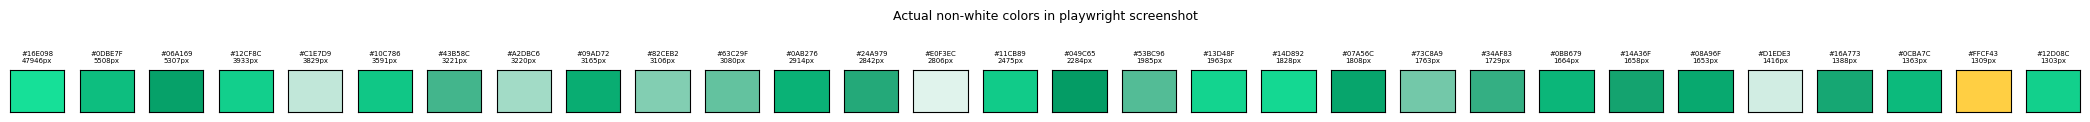

CPU times: user 410 ms, sys: 8.54 ms, total: 419 ms
Wall time: 418 ms


In [6]:
%%time
arr = np.array(screenshot_img)
rgb = arr[:, :, :3]
a   = arr[:, :, 3]

# All opaque, non-white pixels — these are the only candidates for traffic colors
mask          = (a >= 200) & ~((rgb[:,:,0] > 230) & (rgb[:,:,1] > 230) & (rgb[:,:,2] > 230))
colored_pixels = rgb[mask]

colors_uniq, counts = np.unique(colored_pixels.reshape(-1, 3), axis=0, return_counts=True)
order               = np.argsort(-counts)
colors_uniq, counts = colors_uniq[order], counts[order]

print(f'Non-white pixels : {mask.sum():,}  /  {rgb.shape[0]*rgb.shape[1]:,}')
print(f'Unique colors    : {len(colors_uniq)}')
print()
print('Top colors (most common first):')
for i, (c, n) in enumerate(zip(colors_uniq[:30], counts[:30])):
    print(f'  #{c[0]:02X}{c[1]:02X}{c[2]:02X}  RGB({c[0]:3d},{c[1]:3d},{c[2]:3d})  {n:6,} px')

# Visual swatches
n_show = min(30, len(colors_uniq))
fig, axes = plt.subplots(1, n_show, figsize=(n_show * 0.7, 1.2))
if n_show == 1: axes = [axes]
for ax, c, n in zip(axes, colors_uniq[:n_show], counts[:n_show]):
    ax.set_facecolor(tuple(c / 255))
    ax.set_title(f'#{c[0]:02X}{c[1]:02X}{c[2]:02X}\n{n}px', fontsize=5)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Actual non-white colors in playwright screenshot', fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 4 — Color classification helpers

### Why LAB color distance?

The Google Maps JS API renders traffic using 4 specific colors. We classify each pixel
by computing its **CIE76 distance** in perceptually uniform LAB space to each reference,
then assigning the nearest if it's within the threshold.

Because the playwright screenshot has a white background and white roads, we first skip
any near-white pixel (R>230, G>230, B>230) — these are background or normal roads.

### Reference colors (Google Maps JS API TrafficLayer)

| Level | Hex | RGB |
|---|---|---|
| `low` | `#11D68F` | (17, 214, 143) — teal-green |
| `moderate` | `#FFCF43` | (255, 207, 67) — yellow |
| `heavy` | `#F24E42` | (242, 78, 66) — red |
| `severe` | `#A92727` | (169, 39, 39) — dark red |

**Threshold:** 25 CIE76 units.

### `pixel_to_congestion(r, g, b, a)`
Skips white pixels, then finds the nearest reference color in LAB space.

### `latlng_to_pixel(lat, lng, x_min_m, y_max_m, pixel_scale)`
Maps a WGS84 coordinate to pixel (col, row) in the screenshot using EPSG:3857.

### `sample_edge_congestion(geom, screenshot_img, x_min_m, y_max_m, pixel_scale)`
Densely samples 1 point per ~2 m along the edge, checks a 5×5 pixel neighborhood,
and returns the most severe traffic color found.

In [7]:
%%time

def _rgb_to_lab(r, g, b):
    """Convert sRGB (0-255) to CIE LAB (D65 illuminant)."""
    def linearize(c):
        c = c / 255.0
        return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = linearize(r), linearize(g), linearize(b)
    X = (r * 0.4124 + g * 0.3576 + b * 0.1805) / 0.9505
    Y = (r * 0.2126 + g * 0.7152 + b * 0.0722) / 1.0000
    Z = (r * 0.0193 + g * 0.1192 + b * 0.9505) / 1.0890
    def f(t): return t ** (1 / 3) if t > 0.008856 else 7.787 * t + 16 / 116
    return 116 * f(Y) - 16, 500 * (f(X) - f(Y)), 200 * (f(Y) - f(Z))


# Reference colors — Google Maps JS API TrafficLayer (googletraffic R package)
_TRAFFIC_REFS = [
    ('low',      _rgb_to_lab(17,  214, 143)),   # #11D68F teal-green
    ('moderate', _rgb_to_lab(255, 207,  67)),   # #FFCF43 yellow
    ('heavy',    _rgb_to_lab(242,  78,  66)),   # #F24E42 red
    ('severe',   _rgb_to_lab(169,  39,  39)),   # #A92727 dark red
]
_TRAFFIC_THRESHOLD = 25.0   # CIE76 units

print('Reference color sanity check (dist should be 0):')
_REF_RGB = {'low': (17,214,143), 'moderate': (255,207,67), 'heavy': (242,78,66), 'severe': (169,39,39)}
for level, ref_lab in _TRAFFIC_REFS:
    r, g, b = _REF_RGB[level]
    dist = sum((p - q)**2 for p, q in zip(_rgb_to_lab(r, g, b), ref_lab)) ** 0.5
    print(f'  {level:10s}: dist={dist:.6f}  ✓')


def pixel_to_congestion(r, g, b, a):
    """Classify a pixel from the playwright screenshot using LAB color distance."""
    if a < 200:
        return None
    if r > 230 and g > 230 and b > 230:   # white background / white roads
        return None
    lab = _rgb_to_lab(r, g, b)
    best_dist, best_level = float('inf'), None
    for level, ref_lab in _TRAFFIC_REFS:
        dist = sum((p - q) ** 2 for p, q in zip(lab, ref_lab)) ** 0.5
        if dist < best_dist:
            best_dist, best_level = dist, level
    return best_level if best_dist <= _TRAFFIC_THRESHOLD else None


_proj_3857 = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)

def latlng_to_pixel(lat, lng, x_min_m, y_max_m, pixel_scale):
    """Convert WGS84 lat/lng to (col, row) pixel in the playwright screenshot."""
    x, y = _proj_3857.transform(lng, lat)
    return int((x - x_min_m) / pixel_scale), int((y_max_m - y) / pixel_scale)


def sample_edge_congestion(geom, screenshot_img, x_min_m, y_max_m, pixel_scale):
    """Sample the most severe traffic color along an OSM edge from the screenshot."""
    SEVERITY = {'severe': 4, 'heavy': 3, 'moderate': 2, 'low': 1}
    results  = []
    coords = get_coordinates(geom)
    if len(coords) < 2:
        return 'no data'
    line   = LineString(coords)
    from shapely.ops import transform
    line_m = transform(_proj_3857.transform, line)
    n_pts  = max(4, min(int(line_m.length / 2), 200))
    img_w, img_h = screenshot_img.size
    for d in np.linspace(0, 1, n_pts):
        pt  = line.interpolate(d, normalized=True)
        col, row = latlng_to_pixel(pt.y, pt.x, x_min_m, y_max_m, pixel_scale)
        # 3×3 neighborhood — keeps sampling on the road without bleeding to adjacent roads
        for dc in range(-1, 2):
            for dr in range(-1, 2):
                c = max(0, min(img_w - 1, col + dc))
                r = max(0, min(img_h - 1, row + dr))
                cong = pixel_to_congestion(*screenshot_img.getpixel((c, r)))
                if cong:
                    results.append(cong)
    if not results:
        return 'no data'
    return max(results, key=lambda c: SEVERITY.get(c, 0))


print('\nHelpers ready. PALETTE and COLORS defined.')

Reference color sanity check (dist should be 0):
  low       : dist=0.000000  ✓
  moderate  : dist=0.000000  ✓
  heavy     : dist=0.000000  ✓
  severe    : dist=0.000000  ✓

Helpers ready. PALETTE and COLORS defined.
CPU times: user 949 μs, sys: 0 ns, total: 949 μs
Wall time: 576 μs


---
## Step 3a — Build traffic raster matrices

Classify every pixel in the playwright screenshot using vectorized numpy operations
(no per-edge geometry needed yet). Produces:

- **`boundary_raster`** — full area numpy array, shape `(H, W)`, values 0–4
- **`tile_rasters`** — dict `tile → (raster, raw_rgb)` cropped to each mercantile tile
- **`raw_tile_imgs`** — dict `tile → RGB array` (raw screenshot crop, for display)

In [8]:
%%time

def build_traffic_raster(img):
    """
    Classify every pixel using vectorized numpy (float64, matches pixel_to_congestion).
    Returns uint8 array: 0=none 1=low 2=moderate 3=heavy 4=severe
    """
    arr    = np.array(img).astype(np.float64)   # float64 = same precision as pixel_to_congestion
    rgb, a = arr[:, :, :3], arr[:, :, 3]
    mask   = (a >= 200) & ~((rgb[:,:,0] > 230) & (rgb[:,:,1] > 230) & (rgb[:,:,2] > 230))

    c      = rgb / 255.0
    linear = np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)
    Xr = (linear[:,:,0]*0.4124 + linear[:,:,1]*0.3576 + linear[:,:,2]*0.1805) / 0.9505
    Yr =  linear[:,:,0]*0.2126 + linear[:,:,1]*0.7152 + linear[:,:,2]*0.0722
    Zr = (linear[:,:,0]*0.0193 + linear[:,:,1]*0.1192 + linear[:,:,2]*0.9505) / 1.0890
    def f(t): return np.where(t > 0.008856, t ** (1/3), 7.787*t + 16/116)
    lab = np.stack([116*f(Yr) - 16, 500*(f(Xr) - f(Yr)), 200*(f(Yr) - f(Zr))], axis=-1)

    refs  = np.array([ref for _, ref in _TRAFFIC_REFS], dtype=np.float64)  # float64
    diff  = lab[:, :, np.newaxis, :] - refs[np.newaxis, np.newaxis, :, :]
    dists = np.sqrt((diff ** 2).sum(axis=-1))

    raster  = np.zeros(rgb.shape[:2], dtype=np.uint8)
    traffic = mask & (dists.min(axis=-1) <= _TRAFFIC_THRESHOLD)
    raster[traffic] = dists.argmin(axis=-1)[traffic] + 1
    return raster


# ── Full boundary raster ─────────────────────────────────────────────────
img_w, img_h = screenshot_img.size
boundary_raster = build_traffic_raster(screenshot_img)

counts = {name: int((boundary_raster == i+1).sum()) for i, (name, _) in enumerate(_TRAFFIC_REFS)}
total  = int((boundary_raster > 0).sum())
print(f'Boundary raster  : {img_w} × {img_h} px')
print(f'Traffic pixels   : {counts}')
print(f'Total            : {total:,} / {img_w*img_h:,} ({total/img_w/img_h*100:.3f}%)')

# ── Per-tile rasters ─────────────────────────────────────────────────────
tile_rasters  = {}
raw_tile_imgs = {}
full_rgb      = np.array(screenshot_img)[:, :, :3]

for tile in tiles:
    b = mercantile.bounds(tile)
    c0, r0 = latlng_to_pixel(b.north, b.west, x_min_m, y_max_m, PIXEL_SCALE)
    c1, r1 = latlng_to_pixel(b.south, b.east, x_min_m, y_max_m, PIXEL_SCALE)
    c0, r0, c1, r1 = max(0,c0), max(0,r0), min(img_w,c1), min(img_h,r1)
    if c1 <= c0 or r1 <= r0:
        continue
    tile_rasters[tile]  = boundary_raster[r0:r1, c0:c1]
    raw_tile_imgs[tile] = full_rgb[r0:r1, c0:c1]

# ── Save to disk ──────────────────────────────────────────────────────────
raster_dir = OUTPUT_DIR / f'{NAME}_rasters_z{ZOOM}'
raster_dir.mkdir(exist_ok=True)

np.save(str(raster_dir / 'boundary_raster.npy'), boundary_raster)
Image.fromarray(PALETTE[boundary_raster]).save(str(raster_dir / 'boundary_raster.png'))

for tile, raster in tile_rasters.items():
    stem = f'tile_{tile.z}_{tile.x}_{tile.y}'
    np.save(str(raster_dir / f'{stem}.npy'), raster)
    Image.fromarray(PALETTE[raster]).save(str(raster_dir / f'{stem}.png'))
    Image.fromarray(raw_tile_imgs[tile]).save(str(raster_dir / f'{stem}_raw.png'))

print(f'\nSaved to: {raster_dir}/')
print(f'  boundary_raster.npy / .png  +  {len(tile_rasters)} tile files')

Boundary raster  : 4007 × 1760 px
Traffic pixels   : {'low': 105508, 'moderate': 1897, 'heavy': 1036, 'severe': 847}
Total            : 109,288 / 7,052,320 (1.550%)

Saved to: ../output/sodermalm_rasters_z16/
  boundary_raster.npy / .png  +  80 tile files
CPU times: user 1.84 s, sys: 913 ms, total: 2.76 s
Wall time: 2.76 s


---
## Step 3b — Visualize raster matrices

Three panels:
1. **Raw screenshot** — what playwright captured (white background, traffic color stripes)
2. **Boundary raster** — every classified pixel colored by congestion level
3. **Per-tile grid** — each mercantile tile's raw crop and its traffic raster side by side

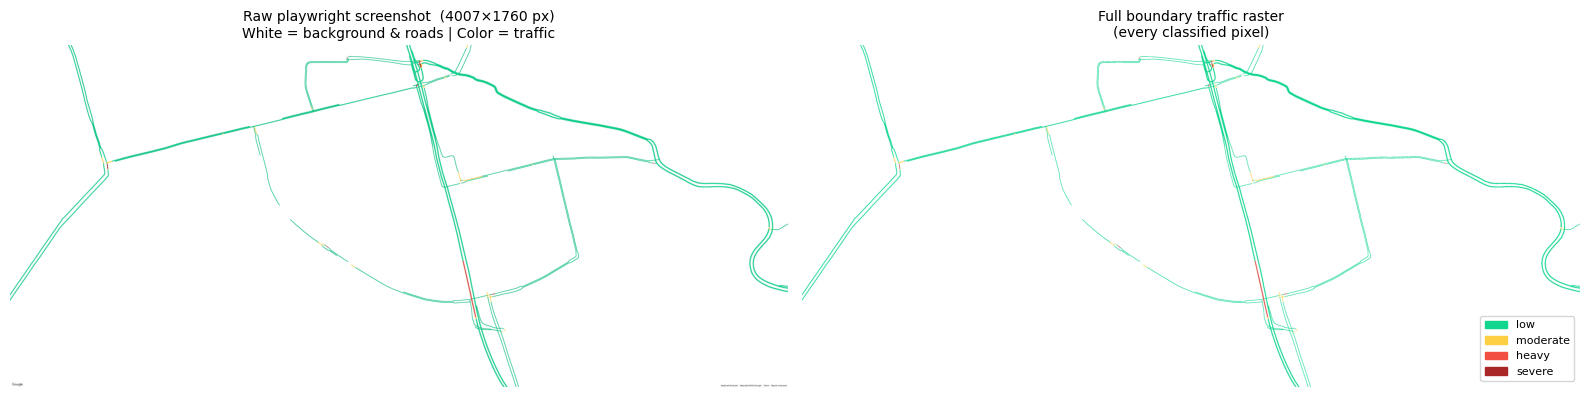

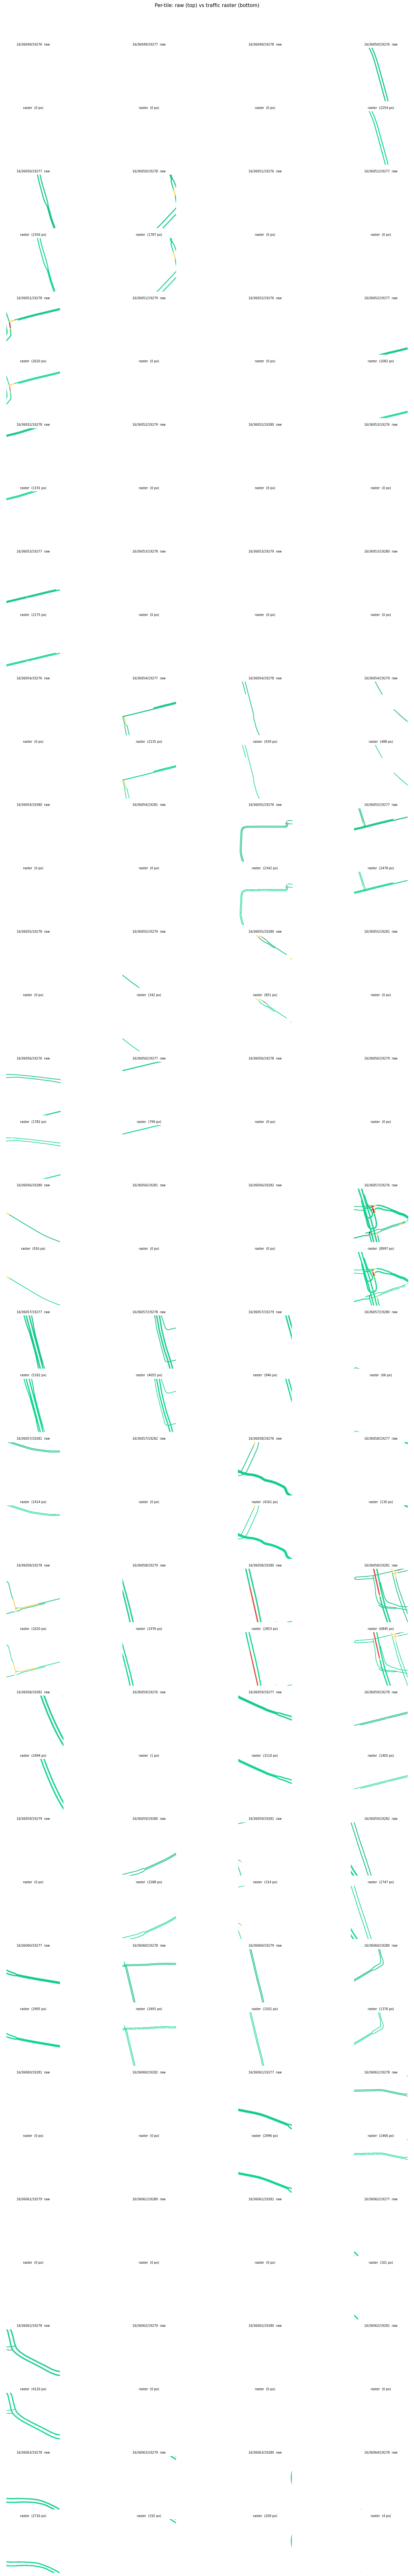

CPU times: user 4.23 s, sys: 84.8 ms, total: 4.31 s
Wall time: 4.38 s


In [9]:
%%time
# PALETTE is defined in the config cell
raw_rgb = np.array(screenshot_img)[:, :, :3]

fig, axes = plt.subplots(1, 2, figsize=(16, int(16 * img_h / img_w / 2) + 2))

axes[0].imshow(raw_rgb)
axes[0].set_title(f'Raw playwright screenshot  ({img_w}×{img_h} px)\nWhite = background & roads | Color = traffic', fontsize=10)
axes[0].axis('off')

axes[1].imshow(PALETTE[boundary_raster])
axes[1].set_title('Full boundary traffic raster\n(every classified pixel)', fontsize=10)
axes[1].axis('off')

from matplotlib.patches import Patch
legend = [Patch(color=np.array(PALETTE[i+1])/255, label=name)
          for i, (name, _) in enumerate(_TRAFFIC_REFS)]
axes[1].legend(handles=legend, loc='lower right', fontsize=8, framealpha=0.8)
plt.tight_layout()
plt.show()

# Per-tile grid
n_tiles = len(tile_rasters)
if n_tiles > 0:
    cols = min(4, n_tiles)
    rows = (n_tiles + cols - 1) // cols
    fig, axes = plt.subplots(rows * 2, cols, figsize=(cols * 4, rows * 4), squeeze=False)
    for idx, (tile, raster) in enumerate(sorted(tile_rasters.items())):
        r, c  = divmod(idx, cols)
        n_px  = int((raster > 0).sum())
        axes[r*2    ][c].imshow(raw_tile_imgs[tile])
        axes[r*2    ][c].set_title(f'{tile.z}/{tile.x}/{tile.y}  raw', fontsize=7)
        axes[r*2    ][c].axis('off')
        axes[r*2 + 1][c].imshow(PALETTE[raster])
        axes[r*2 + 1][c].set_title(f'raster  ({n_px} px)', fontsize=7)
        axes[r*2 + 1][c].axis('off')
    for idx in range(n_tiles, rows * cols):
        r, c = divmod(idx, cols)
        axes[r*2][c].axis('off');  axes[r*2+1][c].axis('off')
    plt.suptitle('Per-tile: raw (top) vs traffic raster (bottom)', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

---
## Step 3b — Inspect the screenshot

Show the raw playwright screenshot alongside the detected traffic pixels sampled
along OSM road edges. Because the screenshot has only white background + traffic
colors, there should be no false positives from labels or signs.

Traffic pixels detected: {'low': 336921, 'moderate': 7947, 'heavy': 5164, 'severe': 3555}
Total                  : 353,587


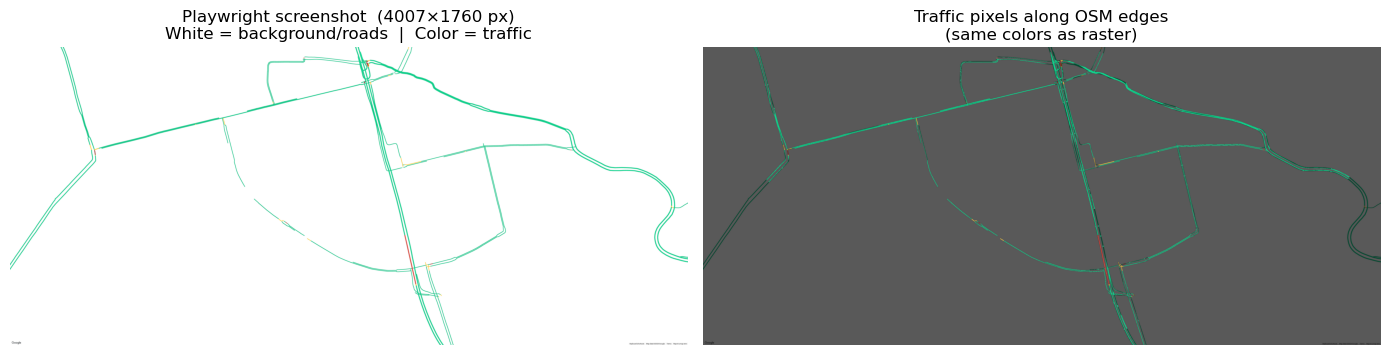

CPU times: user 8.38 s, sys: 46.3 ms, total: 8.43 s
Wall time: 8.45 s


In [10]:
%%time
arr_rgb  = np.array(screenshot_img)[:, :, :3]
img_w, img_h = screenshot_img.size

# Sample along all edges and build a pixel-level overlay
traffic_map  = np.zeros((img_h, img_w), dtype=np.uint8)
pixel_counts = {'low': 0, 'moderate': 0, 'heavy': 0, 'severe': 0}
LEVEL_IDX    = {'low': 1, 'moderate': 2, 'heavy': 3, 'severe': 4}

from shapely.ops import transform as shp_transform

for _, row in edges.iterrows():
    coords = get_coordinates(row.geometry)
    if len(coords) < 2:
        continue
    line   = LineString(coords)
    line_m = shp_transform(_proj_3857.transform, line)
    n_pts  = max(4, min(int(line_m.length / 2), 200))

    for d in np.linspace(0, 1, n_pts):
        pt  = line.interpolate(d, normalized=True)
        col, row_px = latlng_to_pixel(pt.y, pt.x, x_min_m, y_max_m, PIXEL_SCALE)
        for dc in range(-2, 3):
            for dr in range(-2, 3):
                c = max(0, min(img_w - 1, col + dc))
                r = max(0, min(img_h - 1, row_px + dr))
                cong = pixel_to_congestion(*screenshot_img.getpixel((c, r)))
                if cong:
                    traffic_map[r, c] = LEVEL_IDX[cong]
                    pixel_counts[cong] += 1

print(f'Traffic pixels detected: {pixel_counts}')
print(f'Total                  : {sum(pixel_counts.values()):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, int(14 * img_h / img_w) + 1))

axes[0].imshow(arr_rgb)
axes[0].set_title(f'Playwright screenshot  ({img_w}×{img_h} px)\nWhite = background/roads  |  Color = traffic')
axes[0].axis('off')

# Use the same PALETTE as the raster visualization
base_dark = (arr_rgb * 0.35).astype(np.uint8)
mask      = traffic_map > 0
composite = base_dark.copy()
composite[mask] = PALETTE[traffic_map[mask]]
axes[1].imshow(composite)
axes[1].set_title('Traffic pixels along OSM edges\n(same colors as raster)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Step 5 — Bearing-based pixel-to-edge map matching

**Core insight:** Traffic stripes always run *along* roads. At an intersection, a pixel
on Road A (N-S) will have its neighboring traffic pixels also arranged N-S — not E-W.
By estimating the local stripe direction (PCA on neighboring traffic pixels) and comparing
it to candidate edge bearings, crossing roads are rejected geometrically.

### Algorithm
1. Extract all traffic pixels from `boundary_raster` as EPSG:3857 points
2. Build a KD-tree of edge sample points (local bearing stored per point)
3. Build a second KD-tree of traffic pixel positions (for neighbor lookup)
4. For each traffic pixel:
   a. Find neighboring **traffic pixels** within `NEIGHBOR_RADIUS_M` → estimate stripe bearing (PCA)
   b. Find candidate **edge sample points** within `MATCH_BUFFER_M`
   c. Keep only candidates whose local bearing is within `BEARING_THRESHOLD` of stripe bearing
   d. If 0 candidates pass → discard (no direction match)
   e. If candidates share 1 `osm_id` → assign to nearest
   f. If candidates span 2+ `osm_id`s → discard (still ambiguous after bearing filter)
5. Aggregate by edge — most severe level wins

In [15]:
%%time
from scipy.spatial import cKDTree
from shapely.ops import transform as shp_transform
from collections import defaultdict

# Guard: re-load edges if osm_id column is missing (stale kernel)
if 'osm_id' not in edges.columns:
    print("osm_id missing — re-loading edges with updated query...")
    _con = duckdb.connect(str(DB_PATH), read_only=True)
    _con.execute('LOAD spatial')
    _df = _con.execute("""
        SELECT edge_id, source, target, osm_id, highway, name, length_m,
               ST_AsText(geometry) AS wkt_geom
        FROM driving.edges
    """).df()
    _con.close()
    edges = gpd.GeoDataFrame(
        _df,
        geometry=gpd.GeoSeries.from_wkt(_df['wkt_geom']),
        crs='EPSG:4326',
    ).reset_index(drop=True)
    edges = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
    print(f"Re-loaded {len(edges):,} edges with osm_id column.")

MATCH_BUFFER_M    = 10   # metres: candidate edge sample points must be within this
NEIGHBOR_RADIUS_M = 25   # metres: radius for collecting neighboring traffic pixels
BEARING_THRESHOLD = 40   # degrees: max stripe-bearing vs edge-bearing difference
MIN_NEIGHBORS     = 5    # min neighboring traffic pixels needed to estimate direction

# ── 1. All traffic pixels → EPSG:3857 points ─────────────────────────────
traffic_rows, traffic_cols = np.where(boundary_raster > 0)
traffic_vals = boundary_raster[traffic_rows, traffic_cols]

pixel_xs  = x_min_m + traffic_cols * PIXEL_SCALE
pixel_ys  = y_max_m - traffic_rows * PIXEL_SCALE
pixel_pts = np.column_stack([pixel_xs, pixel_ys])
print(f'Traffic pixels        : {len(traffic_vals):,}')

# ── 2. Edge sample points with local bearing per point ────────────────────
edge_sample_pts      = []
edge_sample_eids     = []
edge_sample_oids     = []
edge_sample_bearings = []

for _, row in edges.iterrows():
    geom_m = shp_transform(_proj_3857.transform, row.geometry)
    n_pts  = max(4, min(int(geom_m.length / 2), 500))
    oid    = int(row['osm_id']) if int(row['osm_id']) > 0 else -int(row['edge_id'])
    pts_m  = [geom_m.interpolate(d, normalized=True)
              for d in np.linspace(0.05, 0.95, n_pts)]
    for j, pt in enumerate(pts_m):
        prev = pts_m[max(0, j - 1)]
        nxt  = pts_m[min(len(pts_m) - 1, j + 1)]
        dx, dy  = nxt.x - prev.x, nxt.y - prev.y
        bearing = np.degrees(np.arctan2(dx, dy)) % 180  # undirected 0–180°
        edge_sample_pts.append((pt.x, pt.y))
        edge_sample_eids.append(int(row['edge_id']))
        edge_sample_oids.append(oid)
        edge_sample_bearings.append(bearing)

edge_pts_arr      = np.array(edge_sample_pts)
edge_eids_arr     = np.array(edge_sample_eids,     dtype=np.int64)
edge_oids_arr     = np.array(edge_sample_oids,     dtype=np.int64)
edge_bearings_arr = np.array(edge_sample_bearings, dtype=np.float64)
edge_tree         = cKDTree(edge_pts_arr)
print(f'Edge sample points    : {len(edge_sample_pts):,}')

# ── 3. KD-tree of traffic pixels (for stripe direction estimation) ────────
traffic_tree   = cKDTree(pixel_pts)
nearby_edges   = edge_tree.query_ball_point(pixel_pts, r=MATCH_BUFFER_M)
nearby_traffic = traffic_tree.query_ball_point(pixel_pts, r=NEIGHBOR_RADIUS_M)

# ── 4. Match pixels using bearing + osm_id ────────────────────────────────
INT_TO_LEVEL = {1: 'low', 2: 'moderate', 3: 'heavy', 4: 'severe'}

edge_pixel_vals  = defaultdict(list)
n_matched        = 0
n_no_direction   = 0
n_no_bearing     = 0
n_ambiguous      = 0
n_outside        = 0

for i in range(len(pixel_pts)):
    nb_edges = nearby_edges[i]
    if not nb_edges:
        n_outside += 1
        continue

    nb_tr = nearby_traffic[i]
    if len(nb_tr) < MIN_NEIGHBORS:
        n_no_direction += 1
        continue

    neighbor_pts   = pixel_pts[nb_tr]
    cov            = np.cov(neighbor_pts.T)
    _, eigvecs     = np.linalg.eigh(cov)
    direction      = eigvecs[:, 1]
    stripe_bearing = np.degrees(np.arctan2(direction[0], direction[1])) % 180

    nb_arr  = np.array(nb_edges)
    eb      = edge_bearings_arr[nb_arr]
    diffs   = np.abs(stripe_bearing - eb) % 180
    diffs   = np.minimum(diffs, 180 - diffs)
    ok      = diffs <= BEARING_THRESHOLD

    if not ok.any():
        n_no_bearing += 1
        continue

    nb_filtered = nb_arr[ok]
    unique_oids = np.unique(edge_oids_arr[nb_filtered])
    if len(unique_oids) > 1:
        n_ambiguous += 1
        continue

    dists_local = np.linalg.norm(edge_pts_arr[nb_filtered] - pixel_pts[i], axis=1)
    eid = int(edge_eids_arr[nb_filtered[np.argmin(dists_local)]])
    edge_pixel_vals[eid].append(int(traffic_vals[i]))
    n_matched += 1

edge_congestion = {eid: INT_TO_LEVEL[max(vals)] for eid, vals in edge_pixel_vals.items()}
edges['congestion'] = edges['edge_id'].map(edge_congestion).fillna('no data')

matched_pct = len(edge_congestion) / max(len(edges), 1) * 100
print(f'Pixels matched        : {n_matched:,}')
print(f'No direction (sparse) : {n_no_direction:,}')
print(f'No bearing match      : {n_no_bearing:,}')
print(f'Ambiguous (multi-way) : {n_ambiguous:,}')
print(f'Outside buffer        : {n_outside:,}')
print(f'\nEdges with congestion : {len(edge_congestion):,} / {len(edges):,}  ({matched_pct:.1f}%)')
print('\nCongestion distribution:')
print(edges['congestion'].value_counts().to_string())

osm_id missing — re-loading edges with updated query...
Re-loaded 4,554 edges with osm_id column.
Traffic pixels        : 112,676
Edge sample points    : 183,024
Pixels matched        : 67,149
No direction (sparse) : 0
No bearing match      : 1,680
Ambiguous (multi-way) : 14,205
Outside buffer        : 29,642

Edges with congestion : 419 / 4,554  (9.2%)

Congestion distribution:
congestion
no data     4135
low          369
moderate      29
severe        20
heavy          1
CPU times: user 9.26 s, sys: 359 ms, total: 9.62 s
Wall time: 9.52 s


---
## Step 6 — Write congestion to DuckDB

Controlled by `WRITE_TO_DB` in the config cell. Set it to `False` to inspect
raster and visualization without modifying the database.

When `True`, two writes happen — identical to what the pipeline does:

1. **Latest snapshot** — `driving.edges.congestion_google` and `congestion_google_at` updated
2. **History** — one row per edge appended to `edge_congestion_history` (source=`google`)

In [ ]:
%%time
import sys
sys.path.insert(0, '..')
from traffic_db import TrafficDB

if not WRITE_TO_DB:
    print('WRITE_TO_DB = False — skipping DuckDB write.')
    print(f'(Would have written {len(edge_congestion):,} edges to congestion_google)')
else:
    with TrafficDB(str(DB_PATH), read_only=False) as db:
        run_id = db.write_congestion(
            edge_congestion,
            source        = 'google',
            zoom          = ZOOM,
            n_segments    = total,   # total traffic pixels from build-raster step
            boundary_name = NAME,
        )
    print(f'Run {run_id}  source=google  zoom={ZOOM}')
    print(f'Traffic pixels (n_segments) : {total:,}')
    print(f'congestion_google           : {len(edge_congestion):,} edges updated')

---
## Step 7 — Visualize

The folium map shows every OSM edge colored by the congestion level sampled from
Google Maps. Open Google Maps in another tab and enable the traffic layer on the
same area to compare visually.

| Color | Congestion | Meaning |
|---|---|---|
| 🟢 Green | `low` | Free flow — sampled green pixels |
| 🟠 Orange | `moderate` | Reduced speed — sampled orange/yellow pixels |
| 🔴 Red | `heavy` | Significant slowdown — sampled red pixels |
| ⬛ Dark red | `severe` | Near standstill — sampled dark red pixels |
| ⬜ Gray | `no data` | Tile not available or no traffic pixels on this edge |

In [17]:
%%time
# Hex versions of the JS API reference colors — same as PALETTE
COLORS = {
    'low':      '#11D68F',
    'moderate': '#FFCF43',
    'heavy':    '#F24E42',
    'severe':   '#A92727',
    'no data':  '#cccccc',
}

lines  = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
bds    = lines.total_bounds
center = [(bds[1] + bds[3]) / 2, (bds[0] + bds[2]) / 2]

m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')
folium.GeoJson(
    gdf.__geo_interface__,
    style_function=lambda _: {'color': 'navy', 'weight': 2, 'fillOpacity': 0.05},
    tooltip=None, popup=None,
).add_to(m)
folium.GeoJson(
    lines.__geo_interface__,
    style_function=lambda feat: {
        'color':  COLORS.get(feat['properties'].get('congestion', 'no data'), '#cccccc'),
        'weight': 4 if feat['properties'].get('congestion', 'no data') != 'no data' else 1.5,
    },
    tooltip=None, popup=None,
).add_to(m)
m

CPU times: user 92.9 ms, sys: 3.87 ms, total: 96.8 ms
Wall time: 94.2 ms


---
## Step 8 — Export CSV and GeoJSON

Save the enriched edges as files alongside the Mapbox outputs so they can be
compared or used in QGIS / kepler.gl.

The `_google` suffix in the filename distinguishes these from Mapbox outputs.

In [18]:
%%time
from shapely import get_coordinates as gc

geojson_out = OUTPUT_DIR / f'{NAME}_edges_traffic_google.geojson'
csv_out     = OUTPUT_DIR / f'{NAME}_edges_traffic_google.csv'

edges.to_file(geojson_out, driver='GeoJSON')
print(f'Saved GeoJSON → {geojson_out}  ({len(edges):,} edges)')

csv_df = edges.drop(columns=['geometry','wkt_geom'], errors='ignore').copy()
edges_m = edges.to_crs('EPSG:3857')
centroids        = edges_m.geometry.centroid.to_crs('EPSG:4326')
csv_df['lon']    = centroids.x.round(6)
csv_df['lat']    = centroids.y.round(6)
csv_df['length_m'] = edges_m.geometry.length.round(1)
all_coords           = edges.geometry.apply(gc)
csv_df['start_lon']  = all_coords.apply(lambda c: round(c[ 0][0], 6))
csv_df['start_lat']  = all_coords.apply(lambda c: round(c[ 0][1], 6))
csv_df['end_lon']    = all_coords.apply(lambda c: round(c[-1][0], 6))
csv_df['end_lat']    = all_coords.apply(lambda c: round(c[-1][1], 6))
csv_df.to_csv(csv_out, index=False)
print(f'Saved CSV     → {csv_out}')

print(f'\nFinal congestion distribution:')
print(edges['congestion'].value_counts().to_string())

Saved GeoJSON → ../output/sodermalm_edges_traffic_google.geojson  (4,554 edges)
Saved CSV     → ../output/sodermalm_edges_traffic_google.csv

Final congestion distribution:
congestion
no data     4135
low          369
moderate      29
severe        20
heavy          1
CPU times: user 303 ms, sys: 816 ms, total: 1.12 s
Wall time: 7.69 s
